<a href="https://colab.research.google.com/github/SANGHATI23/genomic-evidence-reliability/blob/main/GES_Stage6D_Cell_6D_1A0_Reviewer_Data_Quality_Perturbation_Robustness_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# GES Stage 6D — Cell 6D-1A0  
## Reviewer-Driven Data-Quality Perturbation Robustness + Reproducibility Freeze

**Purpose.** This notebook addresses the remaining methodological request from the AI Therapeutics Editorial Board:

> Report uncertainty, sensitivity analyses, and performance under data-quality perturbations.

It extends the already-frozen January 2023 → January 2026 temporal validation **without retraining GES, redefining the future outcome, optimizing thresholds, or recalibrating against T1**.

### Scientific question
How sensitive is the **frozen T0-only Full-GES ranking** to plausible degradation or error in the ClinVar metadata available at T0?

### Non-negotiable leakage controls
- The frozen Stage 4C Full-GES model is reused unchanged.
- The frozen Stage 6B temporal outcome is reused unchanged.
- Perturbation scenarios are written to a protocol artifact **before this notebook computes perturbation results**.
- No scenario is selected, removed, or tuned because of its observed AUPRC/AUROC.
- No T1 outcome is used to repair perturbed metadata.
- No clinical-probability claim is made. GES remains a **metadata-derived evidence index / relative warning signal**.

**Important wording:** this is a *revision-motivated prespecified robustness analysis*, not a prospective preregistration, because the main temporal-validation results were already known before the editorial revision request.


In [1]:

# Cell 1 — Colab setup, imports, and deterministic configuration

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import hashlib
import json
import math
import os
import platform
import subprocess
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

MASTER_SEED = 20260907
N_MC = 50  # stochastic replicates per random perturbation scenario

ROOT = Path("/content/drive/MyDrive/GES_RAG_Temporal_Study")

STAGE4B_FEATURES = ROOT / "data_processed/stage4_ges/stage4b_t0_feature_transforms_and_weak_labels_v1.parquet"
STAGE4C_MODEL = ROOT / "models/stage4_ges/stage4c_full_ges_logistic_model_v1.joblib"
STAGE6B_COHORT = ROOT / "data_processed/stage6_temporal_validation/stage6b_locked_primary_evaluable_cohort_v1.parquet"

EXPECTED_SHA256 = {
    "stage4b_features": "c2e9e4f96cd1f61d3962e88d28557dfa1221729b8f79f8fd4d2dafb34847bdb8",
    "stage4c_full_ges_model": "0b4a87b16f768484cbdae168fc226cec5e978521172fb03510bfb1ea3e78fa30",
    "stage6b_evaluable_cohort": "c6ad50dfc376a746e1830d000dba975101d88763fd61b8d1983f6300edb6e038",
}

FEATURES = [
    "recency_score",
    "recency_missing_flag",
    "submitter_diversity_score",
    "review_confidence",
    "aggregate_conflict_flag",
    "scv_group_entropy_normalized",
]

OUTCOME_COL = "primary_future_instability"
KEY_COL = "rcv_accession"
GENE_COL = "target_gene"

OUTDIR = ROOT / "outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
QCDIR = OUTDIR / "quality_checks"
CONFIGDIR = ROOT / "configs"

for d in [OUTDIR, TABLEDIR, FIGDIR, QCDIR, CONFIGDIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("N_MC:", N_MC)
print("Output:", OUTDIR)


Mounted at /content/drive
ROOT: /content/drive/MyDrive/GES_RAG_Temporal_Study
N_MC: 50
Output: /content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1


In [2]:

# Cell 2 — Fail-closed source verification

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

required = {
    "stage4b_features": STAGE4B_FEATURES,
    "stage4c_full_ges_model": STAGE4C_MODEL,
    "stage6b_evaluable_cohort": STAGE6B_COHORT,
}

for name, path in required.items():
    if not path.exists():
        raise FileNotFoundError(f"Required frozen artifact is missing: {path}")
    observed = sha256_file(path)
    expected = EXPECTED_SHA256[name]
    print(f"{name}:")
    print("  observed:", observed)
    print("  expected:", expected)
    if observed != expected:
        raise RuntimeError(
            f"SHA-256 mismatch for {name}. Refusing to run on a non-frozen artifact."
        )

print("\nPASS — all frozen source artifacts match the expected SHA-256 hashes.")


stage4b_features:
  observed: c2e9e4f96cd1f61d3962e88d28557dfa1221729b8f79f8fd4d2dafb34847bdb8
  expected: c2e9e4f96cd1f61d3962e88d28557dfa1221729b8f79f8fd4d2dafb34847bdb8
stage4c_full_ges_model:
  observed: 0b4a87b16f768484cbdae168fc226cec5e978521172fb03510bfb1ea3e78fa30
  expected: 0b4a87b16f768484cbdae168fc226cec5e978521172fb03510bfb1ea3e78fa30
stage6b_evaluable_cohort:
  observed: c6ad50dfc376a746e1830d000dba975101d88763fd61b8d1983f6300edb6e038
  expected: c6ad50dfc376a746e1830d000dba975101d88763fd61b8d1983f6300edb6e038

PASS — all frozen source artifacts match the expected SHA-256 hashes.


In [3]:

# Cell 3 — Freeze the perturbation protocol BEFORE computing perturbation results

PROTOCOL = {
    "protocol_id": "GES_STAGE6D_1A0_DATA_QUALITY_PERTURBATION_V1",
    "analysis_status": "revision-motivated prespecified robustness analysis; not prospective preregistration",
    "master_seed": MASTER_SEED,
    "n_mc_stochastic": N_MC,
    "frozen_inputs": {
        "stage4b_features_sha256": EXPECTED_SHA256["stage4b_features"],
        "stage4c_full_ges_model_sha256": EXPECTED_SHA256["stage4c_full_ges_model"],
        "stage6b_evaluable_cohort_sha256": EXPECTED_SHA256["stage6b_evaluable_cohort"],
    },
    "frozen_model_features": FEATURES,
    "outcome": OUTCOME_COL,
    "primary_metric": "AUPRC",
    "secondary_metrics": [
        "AUROC",
        "Brier score",
        "mean predicted instability risk",
        "Spearman rank correlation vs clean risk",
        "mean absolute score change vs clean risk",
        "top-5-percent risk-set Jaccard vs clean",
        "top-5-percent event enrichment over prevalence",
    ],
    "perturbations": [
        {"id": "recency_missing_05", "kind": "recency_missing", "fraction": 0.05, "stochastic": True},
        {"id": "recency_missing_10", "kind": "recency_missing", "fraction": 0.10, "stochastic": True},
        {"id": "recency_missing_20", "kind": "recency_missing", "fraction": 0.20, "stochastic": True},

        {"id": "submitter_missing_10", "kind": "feature_missing", "feature": "submitter_diversity_score", "fraction": 0.10, "stochastic": True},
        {"id": "review_missing_10", "kind": "feature_missing", "feature": "review_confidence", "fraction": 0.10, "stochastic": True},
        {"id": "entropy_missing_10", "kind": "feature_missing", "feature": "scv_group_entropy_normalized", "fraction": 0.10, "stochastic": True},

        {"id": "conflict_false_negative_10", "kind": "conflict_false_negative", "fraction": 0.10, "stochastic": True},
        {"id": "conflict_false_positive_10", "kind": "conflict_false_positive", "fraction": 0.10, "stochastic": True},

        {"id": "review_downgrade_10", "kind": "review_downgrade", "fraction": 0.10, "levels": 1, "stochastic": True},
        {"id": "review_downgrade_20", "kind": "review_downgrade", "fraction": 0.20, "levels": 1, "stochastic": True},

        {"id": "submitter_undercount_50pct_all", "kind": "submitter_undercount", "multiplier": 0.50, "stochastic": False},

        {"id": "recency_stale_plus_1y_all", "kind": "recency_staleness", "years": 1.0, "stochastic": False},
        {"id": "recency_stale_plus_2y_all", "kind": "recency_staleness", "years": 2.0, "stochastic": False},

        {"id": "combined_missing_10", "kind": "combined_missing", "fraction": 0.10, "stochastic": True},
        {"id": "combined_missing_20", "kind": "combined_missing", "fraction": 0.20, "stochastic": True},
    ],
    "constraints": [
        "No model retraining",
        "No T1-informed repair",
        "No outcome redefinition",
        "No threshold optimization",
        "No recalibration",
        "No scenario removal based on results",
        "Interpretation is metadata robustness, not clinical validation",
    ],
}

PROTOCOL_PATH = CONFIGDIR / "stage6d_1a0_data_quality_perturbation_protocol_v1.json"

def canonical_json(obj):
    return json.dumps(obj, sort_keys=True, indent=2, ensure_ascii=False) + "\n"

payload = canonical_json(PROTOCOL)

if PROTOCOL_PATH.exists():
    existing = PROTOCOL_PATH.read_text(encoding="utf-8")
    if existing != payload:
        raise RuntimeError(
            "A non-identical protocol already exists. Refusing to overwrite it. "
            "Version the protocol explicitly if a scientific change is required."
        )
    print("Protocol already exists and is identical:", PROTOCOL_PATH)
else:
    PROTOCOL_PATH.write_text(payload, encoding="utf-8")
    print("Frozen protocol written:", PROTOCOL_PATH)

print("Protocol SHA-256:", sha256_file(PROTOCOL_PATH))
print("Scenario count:", len(PROTOCOL["perturbations"]))


Frozen protocol written: /content/drive/MyDrive/GES_RAG_Temporal_Study/configs/stage6d_1a0_data_quality_perturbation_protocol_v1.json
Protocol SHA-256: 13f23ba6c88ae63d5d788ef375cc38ef3a344a6199707f84675aa8cf5919d6f3
Scenario count: 15


In [4]:

# Cell 4 — Load frozen data/model, align the evaluable cohort, and reproduce the clean baseline

features_df = pd.read_parquet(STAGE4B_FEATURES)
cohort_df = pd.read_parquet(STAGE6B_COHORT)

if len(features_df) != 71659:
    raise RuntimeError(f"Unexpected Stage4B row count: {len(features_df):,}")
if len(cohort_df) != 66636:
    raise RuntimeError(f"Unexpected Stage6B row count: {len(cohort_df):,}")

for c in [KEY_COL] + FEATURES:
    if c not in features_df.columns:
        raise KeyError(f"Missing required Stage4B column: {c}")

for c in [KEY_COL, OUTCOME_COL]:
    if c not in cohort_df.columns:
        raise KeyError(f"Missing required Stage6B column: {c}")

if features_df[KEY_COL].duplicated().any():
    raise RuntimeError("Stage4B RCV keys are not unique.")
if cohort_df[KEY_COL].duplicated().any():
    raise RuntimeError("Stage6B RCV keys are not unique.")

keep_cohort_cols = [KEY_COL, OUTCOME_COL]
for optional in [GENE_COL, "t0_row_order", "full_ges_instability_risk_t0", "full_ges_p_stable_t0"]:
    if optional in cohort_df.columns and optional not in keep_cohort_cols:
        keep_cohort_cols.append(optional)

analysis_df = cohort_df[keep_cohort_cols].merge(
    features_df[[KEY_COL] + FEATURES],
    on=KEY_COL,
    how="left",
    validate="one_to_one",
)

if analysis_df[FEATURES].isna().all(axis=1).any():
    raise RuntimeError("At least one evaluable RCV failed to link to the frozen Stage4B feature table.")

if "t0_row_order" in analysis_df.columns:
    analysis_df = analysis_df.sort_values("t0_row_order", kind="stable").reset_index(drop=True)
else:
    analysis_df = analysis_df.sort_values(KEY_COL, kind="stable").reset_index(drop=True)

y = analysis_df[OUTCOME_COL].astype(int).to_numpy()
if int(y.sum()) != 6485:
    raise RuntimeError(f"Unexpected future-instability event count: {int(y.sum()):,}")

model_artifact = joblib.load(STAGE4C_MODEL)

if isinstance(model_artifact, dict) and "pipeline" in model_artifact:
    pipeline = model_artifact["pipeline"]
    artifact_feature_names = model_artifact.get("feature_names")
else:
    raise RuntimeError(
        "Unexpected Stage4C model artifact structure. Expected dict with 'pipeline'."
    )

if artifact_feature_names is not None and list(artifact_feature_names) != FEATURES:
    raise RuntimeError(
        f"Frozen model feature mismatch.\nArtifact: {artifact_feature_names}\nExpected: {FEATURES}"
    )

X_clean = analysis_df[FEATURES].copy()
p_stable_clean = pipeline.predict_proba(X_clean)[:, 1]
risk_clean = 1.0 - p_stable_clean

def clean_metrics(y_true, risk):
    return {
        "n": int(len(y_true)),
        "events": int(np.sum(y_true)),
        "prevalence": float(np.mean(y_true)),
        "auprc": float(average_precision_score(y_true, risk)),
        "auroc": float(roc_auc_score(y_true, risk)),
        "brier": float(brier_score_loss(y_true, risk)),
        "mean_risk": float(np.mean(risk)),
    }

BASE = clean_metrics(y, risk_clean)
print(json.dumps(BASE, indent=2))

# Sanity ranges based on the locked Stage 6C analysis.
if abs(BASE["auprc"] - 0.112444) > 0.001:
    raise RuntimeError("Clean AUPRC does not reproduce the locked temporal analysis.")
if abs(BASE["auroc"] - 0.535812) > 0.001:
    raise RuntimeError("Clean AUROC does not reproduce the locked temporal analysis.")
if abs(BASE["prevalence"] - 0.097320) > 0.0001:
    raise RuntimeError("Outcome prevalence does not reproduce the locked temporal analysis.")

if "full_ges_instability_risk_t0" in analysis_df.columns:
    frozen_risk = analysis_df["full_ges_instability_risk_t0"].astype(float).to_numpy()
    max_abs = float(np.nanmax(np.abs(frozen_risk - risk_clean)))
    print("Max |re-scored risk - frozen Stage6B risk| =", max_abs)
    if max_abs > 1e-8:
        raise RuntimeError("Re-scored clean risk does not match the frozen Stage6B Full-GES risk.")

print("\nPASS — frozen clean baseline reproduced.")


{
  "n": 66636,
  "events": 6485,
  "prevalence": 0.09731976709286272,
  "auprc": 0.11244406235413203,
  "auroc": 0.5358121831324858,
  "brier": 0.13754582658959968,
  "mean_risk": 0.06055878932343922
}
Max |re-scored risk - frozen Stage6B risk| = 5.551115123125783e-16

PASS — frozen clean baseline reproduced.


In [5]:

# Cell 5 — Perturbation engine (no outcome access inside perturbation functions)

def seed_for(scenario_id: str, replicate: int) -> int:
    token = f"{MASTER_SEED}|{scenario_id}|{replicate}".encode("utf-8")
    return int(hashlib.sha256(token).hexdigest()[:8], 16)

def choose_indices(rng, eligible_idx, fraction):
    eligible_idx = np.asarray(eligible_idx, dtype=int)
    n = int(round(len(eligible_idx) * float(fraction)))
    n = min(max(n, 0), len(eligible_idx))
    if n == 0:
        return np.array([], dtype=int)
    return rng.choice(eligible_idx, size=n, replace=False)

def perturb(X: pd.DataFrame, spec: dict, replicate: int) -> pd.DataFrame:
    Z = X.copy(deep=True)
    rng = np.random.default_rng(seed_for(spec["id"], replicate))
    kind = spec["kind"]
    all_idx = np.arange(len(Z))

    if kind == "recency_missing":
        idx = choose_indices(rng, all_idx, spec["fraction"])
        Z.loc[idx, "recency_score"] = np.nan
        Z.loc[idx, "recency_missing_flag"] = 1.0

    elif kind == "feature_missing":
        idx = choose_indices(rng, all_idx, spec["fraction"])
        Z.loc[idx, spec["feature"]] = np.nan

    elif kind == "conflict_false_negative":
        eligible = np.flatnonzero(
            pd.to_numeric(Z["aggregate_conflict_flag"], errors="coerce").fillna(0).to_numpy() >= 0.5
        )
        idx = choose_indices(rng, eligible, spec["fraction"])
        Z.loc[idx, "aggregate_conflict_flag"] = 0.0

    elif kind == "conflict_false_positive":
        eligible = np.flatnonzero(
            pd.to_numeric(Z["aggregate_conflict_flag"], errors="coerce").fillna(0).to_numpy() < 0.5
        )
        idx = choose_indices(rng, eligible, spec["fraction"])
        Z.loc[idx, "aggregate_conflict_flag"] = 1.0

    elif kind == "review_downgrade":
        eligible = np.flatnonzero(
            pd.to_numeric(Z["review_confidence"], errors="coerce").fillna(0).to_numpy() > 0
        )
        idx = choose_indices(rng, eligible, spec["fraction"])
        vals = pd.to_numeric(Z.loc[idx, "review_confidence"], errors="coerce")
        Z.loc[idx, "review_confidence"] = np.maximum(0, vals - float(spec["levels"]))

    elif kind == "submitter_undercount":
        s = pd.to_numeric(Z["submitter_diversity_score"], errors="coerce")
        implied_count = np.expm1(s.clip(lower=0))
        degraded_count = implied_count * float(spec["multiplier"])
        Z["submitter_diversity_score"] = np.log1p(degraded_count)

    elif kind == "recency_staleness":
        years = float(spec["years"])
        s = pd.to_numeric(Z["recency_score"], errors="coerce")
        Z["recency_score"] = s * np.exp(-years)

    elif kind == "combined_missing":
        idx = choose_indices(rng, all_idx, spec["fraction"])
        # Simulate partial loss across non-conflict metadata families.
        # Conflict is tested separately as explicit false-positive/false-negative error.
        Z.loc[idx, "recency_score"] = np.nan
        Z.loc[idx, "recency_missing_flag"] = 1.0
        Z.loc[idx, "submitter_diversity_score"] = np.nan
        Z.loc[idx, "review_confidence"] = np.nan
        Z.loc[idx, "scv_group_entropy_normalized"] = np.nan

    else:
        raise ValueError(f"Unknown perturbation kind: {kind}")

    return Z

print("Perturbation functions loaded.")


Perturbation functions loaded.


In [6]:

# Cell 6 — Run all frozen perturbation scenarios

prevalence = float(np.mean(y))
k_top = max(1, int(math.ceil(0.05 * len(y))))
clean_order = np.argsort(-risk_clean, kind="stable")
clean_top = set(clean_order[:k_top].tolist())

def evaluate_perturbed_risk(risk):
    rho = spearmanr(risk_clean, risk, nan_policy="omit").statistic
    order = np.argsort(-risk, kind="stable")
    pert_top = set(order[:k_top].tolist())
    inter = len(clean_top & pert_top)
    union = len(clean_top | pert_top)
    jaccard = inter / union if union else np.nan
    top_event_rate = float(np.mean(y[order[:k_top]]))
    enrichment = top_event_rate / prevalence if prevalence > 0 else np.nan

    return {
        "auprc": float(average_precision_score(y, risk)),
        "auroc": float(roc_auc_score(y, risk)),
        "brier": float(brier_score_loss(y, risk)),
        "mean_risk": float(np.mean(risk)),
        "spearman_vs_clean": float(rho),
        "mae_risk_vs_clean": float(np.mean(np.abs(risk - risk_clean))),
        "top5_jaccard_vs_clean": float(jaccard),
        "top5_event_rate": top_event_rate,
        "top5_event_enrichment": float(enrichment),
    }

rows = []
scenarios = PROTOCOL["perturbations"]
started = time.time()

for s_i, spec in enumerate(scenarios, start=1):
    n_rep = N_MC if spec.get("stochastic", True) else 1
    print(f"[{s_i:02d}/{len(scenarios):02d}] {spec['id']} — {n_rep} replicate(s)")
    for rep in range(n_rep):
        Xp = perturb(X_clean, spec, rep)
        p_stable = pipeline.predict_proba(Xp[FEATURES])[:, 1]
        risk = 1.0 - p_stable
        m = evaluate_perturbed_risk(risk)

        rows.append({
            "scenario_id": spec["id"],
            "kind": spec["kind"],
            "replicate": rep,
            "stochastic": bool(spec.get("stochastic", True)),
            **m,
            "delta_auprc_vs_clean": m["auprc"] - BASE["auprc"],
            "delta_auroc_vs_clean": m["auroc"] - BASE["auroc"],
            "delta_brier_vs_clean": m["brier"] - BASE["brier"],
        })

results = pd.DataFrame(rows)
elapsed = time.time() - started

print(f"\nCompleted {len(results):,} perturbation evaluations in {elapsed/60:.2f} minutes.")
print(results.head())


[01/15] recency_missing_05 — 50 replicate(s)
[02/15] recency_missing_10 — 50 replicate(s)
[03/15] recency_missing_20 — 50 replicate(s)
[04/15] submitter_missing_10 — 50 replicate(s)
[05/15] review_missing_10 — 50 replicate(s)
[06/15] entropy_missing_10 — 50 replicate(s)
[07/15] conflict_false_negative_10 — 50 replicate(s)
[08/15] conflict_false_positive_10 — 50 replicate(s)
[09/15] review_downgrade_10 — 50 replicate(s)
[10/15] review_downgrade_20 — 50 replicate(s)
[11/15] submitter_undercount_50pct_all — 1 replicate(s)
[12/15] recency_stale_plus_1y_all — 1 replicate(s)
[13/15] recency_stale_plus_2y_all — 1 replicate(s)
[14/15] combined_missing_10 — 50 replicate(s)
[15/15] combined_missing_20 — 50 replicate(s)

Completed 603 perturbation evaluations in 0.76 minutes.
          scenario_id             kind  replicate  stochastic     auprc  \
0  recency_missing_05  recency_missing          0        True  0.111984   
1  recency_missing_05  recency_missing          1        True  0.112389   

In [7]:

# Cell 7 — Summarize uncertainty across perturbation replicates

def q025(x): return np.quantile(x, 0.025)
def q975(x): return np.quantile(x, 0.975)

summary = (
    results.groupby(["scenario_id", "kind"], as_index=False)
    .agg(
        n_replicates=("replicate", "count"),
        auprc_median=("auprc", "median"),
        auprc_q025=("auprc", q025),
        auprc_q975=("auprc", q975),
        delta_auprc_median=("delta_auprc_vs_clean", "median"),
        delta_auprc_q025=("delta_auprc_vs_clean", q025),
        delta_auprc_q975=("delta_auprc_vs_clean", q975),
        auroc_median=("auroc", "median"),
        auroc_q025=("auroc", q025),
        auroc_q975=("auroc", q975),
        brier_median=("brier", "median"),
        mean_risk_median=("mean_risk", "median"),
        spearman_median=("spearman_vs_clean", "median"),
        spearman_q025=("spearman_vs_clean", q025),
        spearman_q975=("spearman_vs_clean", q975),
        risk_mae_median=("mae_risk_vs_clean", "median"),
        top5_jaccard_median=("top5_jaccard_vs_clean", "median"),
        top5_event_enrichment_median=("top5_event_enrichment", "median"),
    )
)

summary.insert(2, "clean_auprc", BASE["auprc"])
summary.insert(3, "clean_auroc", BASE["auroc"])
summary.insert(4, "clean_brier", BASE["brier"])

pd.set_option("display.max_columns", None)
display(summary)

raw_path = TABLEDIR / "stage6d_1a0_perturbation_replicate_results_v1.csv"
summary_path = TABLEDIR / "stage6d_1a0_perturbation_summary_v1.csv"

results.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)

print("\nSaved:")
print(raw_path)
print(summary_path)


,scenario_id,kind,clean_auprc,clean_auroc,clean_brier,n_replicates,auprc_median,auprc_q025,auprc_q975,delta_auprc_median,delta_auprc_q025,delta_auprc_q975,auroc_median,auroc_q025,auroc_q975,brier_median,mean_risk_median,spearman_median,spearman_q025,spearman_q975,risk_mae_median,top5_jaccard_median,top5_event_enrichment_median
0,combined_missing_10,combined_missing,0.112444,0.535812,0.137546,50,0.109653,0.108248,0.111241,-0.002791,-0.004196,-0.001203,0.531063,0.527968,0.535794,0.177976,0.131601,0.836523,0.833636,0.840280,0.071604,0.588937,1.378483
1,combined_missing_20,combined_missing,0.112444,0.535812,0.137546,50,0.107586,0.106485,0.109886,-0.004858,-0.005959,-0.002558,0.525993,0.522697,0.531448,0.218458,0.202615,0.691746,0.685923,0.695899,0.143147,0.559378,1.285968
2,conflict_false_negative_10,conflict_false_negative,0.112444,0.535812,0.137546,50,0.111318,0.110320,0.112364,-0.001126,-0.002124,-0.000080,0.535052,0.534432,0.535553,0.136245,0.058369,0.998067,0.997885,0.998263,0.002190,0.915493,1.205787
3,conflict_false_positive_10,conflict_false_positive,0.112444,0.535812,0.137546,50,0.105988,0.104225,0.107779,-0.006456,-0.008219,-0.004665,0.530604,0.527977,0.534016,0.195691,0.137383,0.840269,0.836967,0.843961,0.076825,0.190638,1.483334
4,entropy_missing_10,feature_missing,0.112444,0.535812,0.137546,50,0.112376,0.112186,0.112548,-0.000068,-0.000258,0.000104,0.535763,0.535686,0.535819,0.137534,0.060544,0.999944,0.999917,0.999960,0.000015,0.998501,1.295219
5,recency_missing_05,recency_missing,0.112444,0.535812,0.137546,50,0.112342,0.110974,0.113260,-0.000102,-0.001470,0.000816,0.537077,0.534278,0.538934,0.151866,0.086210,0.945700,0.943848,0.947182,0.025881,0.701736,1.398528
6,recency_missing_10,recency_missing,0.112444,0.535812,0.137546,50,0.112223,0.111201,0.113630,-0.000221,-0.001243,0.001186,0.537790,0.534457,0.541066,0.166119,0.111771,0.895000,0.892046,0.897088,0.051711,0.614537,1.435534
7,recency_missing_20,recency_missing,0.112444,0.535812,0.137546,50,0.112324,0.110891,0.114269,-0.000120,-0.001553,0.001825,0.540334,0.535892,0.544573,0.195012,0.162991,0.805748,0.802748,0.808445,0.103409,0.568000,1.421657
8,recency_stale_plus_1y_all,recency_staleness,0.112444,0.535812,0.137546,1,0.121005,0.121005,0.121005,0.008561,0.008561,0.008561,0.558437,0.558437,0.558437,0.662686,0.734408,0.911862,0.911862,0.911862,0.673849,0.540097,1.474083
9,recency_stale_plus_2y_all,recency_staleness,0.112444,0.535812,0.137546,1,0.121628,0.121628,0.121628,0.009183,0.009183,0.009183,0.563767,0.563767,0.563767,0.759570,0.869042,0.868381,0.868381,0.868381,0.808483,0.527389,1.628275



Saved:
/content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1/tables/stage6d_1a0_perturbation_replicate_results_v1.csv
/content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1/tables/stage6d_1a0_perturbation_summary_v1.csv


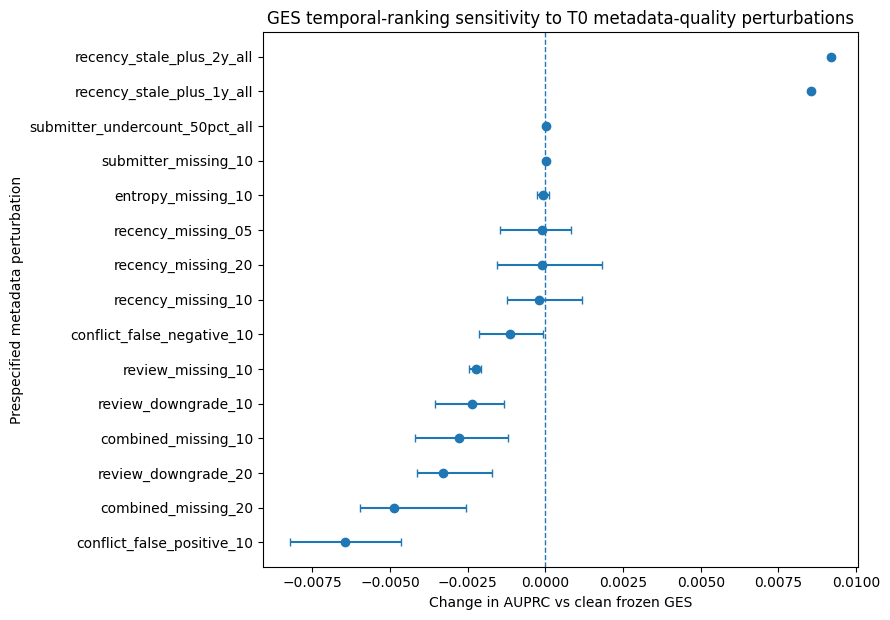

,scenario_id,n_replicates,auprc_median,auprc_q025,auprc_q975,delta_auprc_median,auroc_median,brier_median,spearman_median,top5_jaccard_median,top5_event_enrichment_median
0,combined_missing_10,50,0.109653,0.108248,0.111241,-0.002791,0.531063,0.177976,0.836523,0.588937,1.378483
1,combined_missing_20,50,0.107586,0.106485,0.109886,-0.004858,0.525993,0.218458,0.691746,0.559378,1.285968
2,conflict_false_negative_10,50,0.111318,0.110320,0.112364,-0.001126,0.535052,0.136245,0.998067,0.915493,1.205787
3,conflict_false_positive_10,50,0.105988,0.104225,0.107779,-0.006456,0.530604,0.195691,0.840269,0.190638,1.483334
4,entropy_missing_10,50,0.112376,0.112186,0.112548,-0.000068,0.535763,0.137534,0.999944,0.998501,1.295219
5,recency_missing_05,50,0.112342,0.110974,0.113260,-0.000102,0.537077,0.151866,0.945700,0.701736,1.398528
6,recency_missing_10,50,0.112223,0.111201,0.113630,-0.000221,0.537790,0.166119,0.895000,0.614537,1.435534
7,recency_missing_20,50,0.112324,0.110891,0.114269,-0.000120,0.540334,0.195012,0.805748,0.568000,1.421657
8,recency_stale_plus_1y_all,1,0.121005,0.121005,0.121005,0.008561,0.558437,0.662686,0.911862,0.540097,1.474083
9,recency_stale_plus_2y_all,1,0.121628,0.121628,0.121628,0.009183,0.563767,0.759570,0.868381,0.527389,1.628275


Figure: /content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1/figures/stage6d_1a0_auprc_delta_data_quality_perturbations_v1.png
Manuscript table: /content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1/tables/stage6d_1a0_manuscript_ready_robustness_table_v1.csv


In [8]:

# Cell 8 — Manuscript-ready robustness figure and compact table

plot_df = summary.copy().sort_values("delta_auprc_median")
ypos = np.arange(len(plot_df))

x = plot_df["delta_auprc_median"].to_numpy()
xerr_low = x - plot_df["delta_auprc_q025"].to_numpy()
xerr_high = plot_df["delta_auprc_q975"].to_numpy() - x

fig, ax = plt.subplots(figsize=(9, max(6, 0.42 * len(plot_df))))
ax.errorbar(
    x,
    ypos,
    xerr=np.vstack([xerr_low, xerr_high]),
    fmt="o",
    capsize=3,
)
ax.axvline(0.0, linestyle="--", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["scenario_id"])
ax.set_xlabel("Change in AUPRC vs clean frozen GES")
ax.set_ylabel("Prespecified metadata perturbation")
ax.set_title("GES temporal-ranking sensitivity to T0 metadata-quality perturbations")
fig.tight_layout()

fig_path = FIGDIR / "stage6d_1a0_auprc_delta_data_quality_perturbations_v1.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

manuscript_table = summary[
    [
        "scenario_id",
        "n_replicates",
        "auprc_median",
        "auprc_q025",
        "auprc_q975",
        "delta_auprc_median",
        "auroc_median",
        "brier_median",
        "spearman_median",
        "top5_jaccard_median",
        "top5_event_enrichment_median",
    ]
].copy()

manuscript_table_path = TABLEDIR / "stage6d_1a0_manuscript_ready_robustness_table_v1.csv"
manuscript_table.to_csv(manuscript_table_path, index=False)

display(manuscript_table)
print("Figure:", fig_path)
print("Manuscript table:", manuscript_table_path)


In [9]:

# Cell 9 — Reproducibility record: package versions, remote Git commit, source hashes

REPO_URL = "https://github.com/SANGHATI23/genomic-evidence-reliability.git"

def get_remote_head(repo_url):
    try:
        out = subprocess.check_output(
            ["git", "ls-remote", repo_url, "HEAD"],
            stderr=subprocess.STDOUT,
            text=True,
            timeout=30,
        ).strip()
        return out.split()[0] if out else None
    except Exception as e:
        print("WARNING: could not resolve remote Git HEAD:", repr(e))
        return None

git_head = get_remote_head(REPO_URL)

env = {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "scipy": __import__("scipy").__version__,
    "joblib": joblib.__version__,
    "matplotlib": __import__("matplotlib").__version__,
    "pyarrow": __import__("pyarrow").__version__,
}

repro_record = {
    "analysis_id": PROTOCOL["protocol_id"],
    "executed_utc": pd.Timestamp.utcnow().isoformat(),
    "repository": REPO_URL,
    "remote_git_head_at_execution": git_head,
    "source_artifacts": {
        str(STAGE4B_FEATURES): sha256_file(STAGE4B_FEATURES),
        str(STAGE4C_MODEL): sha256_file(STAGE4C_MODEL),
        str(STAGE6B_COHORT): sha256_file(STAGE6B_COHORT),
        str(PROTOCOL_PATH): sha256_file(PROTOCOL_PATH),
    },
    "clean_baseline": BASE,
    "environment": env,
    "output_files": {
        "replicate_results": str(raw_path),
        "summary": str(summary_path),
        "manuscript_table": str(manuscript_table_path),
        "figure": str(fig_path),
    },
    "interpretation_boundary": (
        "This analysis quantifies sensitivity of the frozen metadata-derived GES index "
        "to simulated T0 metadata degradation. It does not establish clinical validity, "
        "patient-level predictive accuracy, or calibrated probability."
    ),
}

repro_path = QCDIR / "stage6d_1a0_reproducibility_record_v1.json"
repro_path.write_text(canonical_json(repro_record), encoding="utf-8")

pip_freeze_path = QCDIR / "stage6d_1a0_pip_freeze_v1.txt"
try:
    pip_freeze = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True, timeout=120
    )
    pip_freeze_path.write_text(pip_freeze, encoding="utf-8")
except Exception as e:
    pip_freeze_path.write_text(f"pip freeze unavailable: {repr(e)}\n", encoding="utf-8")

print("Remote Git HEAD:", git_head)
print("Reproducibility record:", repro_path)
print("pip freeze:", pip_freeze_path)
display(pd.DataFrame([env]))


Remote Git HEAD: 32cb7af2b565117cc2852e5ad92de3b2e5447091
Reproducibility record: /content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1/quality_checks/stage6d_1a0_reproducibility_record_v1.json
pip freeze: /content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1/quality_checks/stage6d_1a0_pip_freeze_v1.txt


,python,platform,numpy,pandas,scikit_learn,scipy,joblib,matplotlib,pyarrow
0,"3.13.15 (main, Aug 6 2026, 11:06:23) [GCC 11....",Linux-6.6.122+-x86_64-with-glibc2.35,2.1.3,2.2.3,1.6.1,1.16.3,1.5.3,3.10.0,18.1.0


In [10]:

# Cell 10 — Final manifest, SHA-256 sidecars, QC, and reviewer-facing interpretation skeleton

artifacts = [
    PROTOCOL_PATH,
    raw_path,
    summary_path,
    manuscript_table_path,
    fig_path,
    repro_path,
    pip_freeze_path,
]

manifest_rows = []
for p in artifacts:
    if not Path(p).exists():
        raise FileNotFoundError(f"Expected output missing: {p}")
    manifest_rows.append({
        "artifact": str(p),
        "bytes": Path(p).stat().st_size,
        "sha256": sha256_file(Path(p)),
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = QCDIR / "stage6d_1a0_output_manifest_v1.csv"
manifest_df.to_csv(manifest_path, index=False)

for p in artifacts + [manifest_path]:
    p = Path(p)
    sidecar = p.with_name(p.name + ".sha256")
    sidecar.write_text(f"{sha256_file(p)}  {p.name}\n", encoding="utf-8")

print("FINAL QC")
print("--------")
print("Clean n:", BASE["n"])
print("Clean events:", BASE["events"])
print("Clean prevalence:", BASE["prevalence"])
print("Clean AUPRC:", BASE["auprc"])
print("Clean AUROC:", BASE["auroc"])
print("Perturbation scenarios:", summary["scenario_id"].nunique())
print("Perturbation evaluations:", len(results))
print("Manifest:", manifest_path)

display(manifest_df)

worst = summary.loc[summary["delta_auprc_median"].idxmin()]
best = summary.loc[summary["delta_auprc_median"].idxmax()]

reviewer_text = f'''
Data-quality perturbation analysis:
The frozen T0-only GES model was re-evaluated without retraining after prespecified
simulations of missing, stale, undercounted, downgraded, or mis-recorded metadata.
Across {summary["scenario_id"].nunique()} perturbation scenarios, the clean temporal
AUPRC was {BASE["auprc"]:.6f} and AUROC was {BASE["auroc"]:.6f}. The largest median
AUPRC decrease was observed under "{worst["scenario_id"]}"
(delta={worst["delta_auprc_median"]:+.6f}), while the largest median change in the
opposite direction occurred under "{best["scenario_id"]}"
(delta={best["delta_auprc_median"]:+.6f}). Rank stability and top-5% overlap are
reported alongside discrimination and Brier score. These perturbations assess
metadata robustness only and do not convert GES into a calibrated clinical probability.
'''

print("\nReviewer-facing interpretation skeleton:")
print(reviewer_text)
print("\nPASS — Stage 6D-1A0 outputs frozen successfully.")


FINAL QC
--------
Clean n: 66636
Clean events: 6485
Clean prevalence: 0.09731976709286272
Clean AUPRC: 0.11244406235413203
Clean AUROC: 0.5358121831324858
Perturbation scenarios: 15
Perturbation evaluations: 603
Manifest: /content/drive/MyDrive/GES_RAG_Temporal_Study/outputs/stage6_temporal_validation/stage6d_1a0_data_quality_perturbation_v1/quality_checks/stage6d_1a0_output_manifest_v1.csv


,artifact,bytes,sha256
0,/content/drive/MyDrive/GES_RAG_Temporal_Study/...,3613,13f23ba6c88ae63d5d788ef375cc38ef3a344a6199707f...
1,/content/drive/MyDrive/GES_RAG_Temporal_Study/...,173062,4c1a055adafb8da3184353895e4e0700833a3ff5efd39b...
2,/content/drive/MyDrive/GES_RAG_Temporal_Study/...,6866,08a863e8fd813226d2c2f4623f0f797f31184f3db250e3...
3,/content/drive/MyDrive/GES_RAG_Temporal_Study/...,3148,c272d5b4061ce8a670a6d0bd0cd434762b60fe6f76183c...
4,/content/drive/MyDrive/GES_RAG_Temporal_Study/...,267474,30566428dcd02b1e642eb4431df2e2c8b1e647517cf735...
5,/content/drive/MyDrive/GES_RAG_Temporal_Study/...,2736,ff1630a64730f1c73d9ea371f25072e5db71abea775825...
6,/content/drive/MyDrive/GES_RAG_Temporal_Study/...,14017,9ef4483a08961557d42bbc8d0e8028fe9d38d2617da989...



Reviewer-facing interpretation skeleton:

Data-quality perturbation analysis:
The frozen T0-only GES model was re-evaluated without retraining after prespecified
simulations of missing, stale, undercounted, downgraded, or mis-recorded metadata.
Across 15 perturbation scenarios, the clean temporal
AUPRC was 0.112444 and AUROC was 0.535812. The largest median
AUPRC decrease was observed under "conflict_false_positive_10"
(delta=-0.006456), while the largest median change in the
opposite direction occurred under "recency_stale_plus_2y_all"
(delta=+0.009183). Rank stability and top-5% overlap are
reported alongside discrimination and Brier score. These perturbations assess
metadata robustness only and do not convert GES into a calibrated clinical probability.


PASS — Stage 6D-1A0 outputs frozen successfully.



## What to carry into the Springer revision

Use the **clean temporal-validation results as the primary independent validation**. Add this Stage 6D perturbation analysis as a dedicated robustness subsection.

**Methods — Data-quality perturbation sensitivity.** State that the already-frozen T0 model and T1 future outcome were held fixed and that plausible metadata degradation was simulated without retraining or T1-informed repair.

**Results — Robustness to metadata degradation.** Report the clean AUPRC/AUROC, the perturbation table, the largest observed degradation, rank correlations, and top-risk-set stability. Report negative or heterogeneous findings exactly as observed.

**Discussion.** Interpret the experiment as robustness of a metadata-derived evidence index. Do not describe it as patient-level validation, clinical probability calibration, or evidence that any threshold is suitable for therapeutic decision-making.

### After this notebook
The next revision-support task should be a **reference-authenticity and claim-support audit** of every citation in the revised chapter, followed by the final reproducibility/package freeze and point-by-point response letter.
